a_tokenize_embed
====================
Stage 1 of the masked multi-head attention walkthrough.

Pipeline:
    sentence
      → HuggingFace tokenizer  (GPT-2 BPE)
      → token ids
      → embedding lookup       (learned d_model-dim vectors)
      → sinusoidal positional encoding  (added, not concatenated)
      → save final embedding matrix to disk for script 02

Everything is printed step-by-step so each shape transformation is visible.
The embedding matrix is saved as a .pt file and also visualised as a heatmap.

In [10]:
cd "/content/drive/MyDrive/Courses/AI/masked_attention"

/content/drive/MyDrive/Courses/AI/masked_attention


In [11]:
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from transformers import AutoTokenizer

In [12]:
# ── Config ────────────────────────────────────────────────────────────────────

SENTENCE = "the cat sat on the mat"
MODEL_ID  = "gpt2"          # BPE tokenizer; vocab ~50k
D_MODEL   = 64              # small so matrices are readable on screen
SAVE_PT   = "embeddings.pt" # consumed by script 02

torch.manual_seed(0)

In [13]:
# ── 1. Tokenise ───────────────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

# encode() returns plain Python list of ints
token_ids = tokenizer.encode(SENTENCE)
tokens    = tokenizer.convert_ids_to_tokens(token_ids)
T         = len(token_ids)          # sequence length

print("=" * 60)
print("STEP 1 — TOKENISATION")
print("=" * 60)
print(f"  Sentence : '{SENTENCE}'")
print(f"  Tokens   : {tokens}")
print(f"  IDs      : {token_ids}")
print(f"  Seq len  : T = {T}")

# shape check: token_ids is a Python list, turn into 1-D tensor
ids_tensor = torch.tensor(token_ids)          # (T,)
print(f"\n  ids_tensor  shape : {ids_tensor.shape}   dtype: {ids_tensor.dtype}")

STEP 1 — TOKENISATION
  Sentence : 'the cat sat on the mat'
  Tokens   : ['the', 'Ġcat', 'Ġsat', 'Ġon', 'Ġthe', 'Ġmat']
  IDs      : [1169, 3797, 3332, 319, 262, 2603]
  Seq len  : T = 6

  ids_tensor  shape : torch.Size([6])   dtype: torch.int64


In [14]:
# ── 2. Token Embedding ────────────────────────────────────────────────────────
#
# nn.Embedding is just a lookup table: E ∈ R^{vocab × d_model}
# For each token id i we retrieve E[i], giving a (T, d_model) matrix.

VOCAB_SIZE = tokenizer.vocab_size               # 50 257 for GPT-2
embedding  = torch.nn.Embedding(VOCAB_SIZE, D_MODEL)
# default init: N(0,1) — fine for illustration; real models use smaller std

tok_emb = embedding(ids_tensor)                 # (T, d_model)

print("\n" + "=" * 60)
print("STEP 2 — TOKEN EMBEDDING LOOKUP")
print("=" * 60)
print(f"  Embedding table shape : {embedding.weight.shape}  (vocab × d_model)")
print(f"  ids_tensor            : {ids_tensor.shape}  → one row per token")
print(f"  tok_emb               : {tok_emb.shape}     (T × d_model)")
print(f"\n  tok_emb[0]  ('{tokens[0]}') = {tok_emb[0].detach().numpy().round(3)[:8]} ...")


STEP 2 — TOKEN EMBEDDING LOOKUP
  Embedding table shape : torch.Size([50257, 64])  (vocab × d_model)
  ids_tensor            : torch.Size([6])  → one row per token
  tok_emb               : torch.Size([6, 64])     (T × d_model)

  tok_emb[0]  ('the') = [ 0.705  1.74   1.403 -0.819 -0.029  0.083  1.48  -1.297] ...


In [15]:
# ── 3. Sinusoidal Positional Encoding ─────────────────────────────────────────
#
# From "Attention Is All You Need" (Vaswani et al., 2017):
#
#   PE(pos, 2i)   = sin( pos / 10000^(2i / d_model) )
#   PE(pos, 2i+1) = cos( pos / 10000^(2i / d_model) )
#
# pos ∈ {0, …, T-1}   i ∈ {0, …, d_model/2 - 1}
#
# Key property: PE(pos+k) can be expressed as a linear function of PE(pos),
# so the model can reason about relative distances.

def sinusoidal_pe(seq_len: int, d_model: int) -> torch.Tensor:
    """Return PE matrix of shape (seq_len, d_model). No learned parameters."""
    pos = torch.arange(seq_len).unsqueeze(1)          # (T, 1)
    i   = torch.arange(0, d_model, 2)                 # even indices: 0,2,4,...

    # division term: 10000^(2i/d_model)  — computed in log space for stability
    div = torch.exp(i * (-torch.log(torch.tensor(10000.0)) / d_model))

    pe = torch.zeros(seq_len, d_model)
    pe[:, 0::2] = torch.sin(pos * div)   # even dimensions  → sin
    pe[:, 1::2] = torch.cos(pos * div)   # odd  dimensions  → cos
    return pe                             # (T, d_model)

pe = sinusoidal_pe(T, D_MODEL)            # (T, d_model)

print("\n" + "=" * 60)
print("STEP 3 — SINUSOIDAL POSITIONAL ENCODING")
print("=" * 60)
print(f"  PE shape : {pe.shape}  (no learned params)")
print(f"\n  PE[0] (pos=0) = {pe[0].numpy().round(3)[:8]} ...")
print(f"  PE[1] (pos=1) = {pe[1].numpy().round(3)[:8]} ...")
print(f"\n  Note: PE[0] starts with sin(0)=0, cos(0)=1 for each frequency.")


STEP 3 — SINUSOIDAL POSITIONAL ENCODING
  PE shape : torch.Size([6, 64])  (no learned params)

  PE[0] (pos=0) = [0. 1. 0. 1. 0. 1. 0. 1.] ...
  PE[1] (pos=1) = [0.841 0.54  0.682 0.732 0.533 0.846 0.409 0.912] ...

  Note: PE[0] starts with sin(0)=0, cos(0)=1 for each frequency.


In [16]:
# ── 4. Add Positional Encoding to Token Embeddings ───────────────────────────
#
# x = tok_emb + pe   — both (T, d_model), element-wise addition
# The model now has both semantic (token) and positional information in each row.

x = tok_emb + pe                          # (T, d_model)

print("\n" + "=" * 60)
print("STEP 4 — COMBINED INPUT REPRESENTATION  x = tok_emb + pe")
print("=" * 60)
print(f"  tok_emb : {tok_emb.shape}")
print(f"  pe      : {pe.shape}")
print(f"  x       : {x.shape}   ← this is the input to the attention layer")
print(f"\n  x[0] ('{tokens[0]}') = {x[0].detach().numpy().round(3)[:8]} ...")


STEP 4 — COMBINED INPUT REPRESENTATION  x = tok_emb + pe
  tok_emb : torch.Size([6, 64])
  pe      : torch.Size([6, 64])
  x       : torch.Size([6, 64])   ← this is the input to the attention layer

  x[0] ('the') = [ 0.705  2.74   1.403  0.181 -0.029  1.083  1.48  -0.297] ...


In [17]:
# ── 5. Save for script 02 ─────────────────────────────────────────────────────

payload = {
    "x":        x.detach(),       # (T, d_model)  — input embeddings
    "tok_emb":  tok_emb.detach(), # (T, d_model)  — token part only
    "pe":       pe,               # (T, d_model)  — positional part only
    "token_ids":ids_tensor,       # (T,)
    "tokens":   tokens,           # list[str]
    "T":        T,
    "D_MODEL":  D_MODEL,
    "VOCAB_SIZE": VOCAB_SIZE,
    "SENTENCE": SENTENCE,
    # save the embedding table weights so script 02 can reuse them for the
    # final unembed step (weight tying: output projection = embedding.T)
    "emb_weight": embedding.weight.detach(),  # (vocab, d_model)
}
torch.save(payload, SAVE_PT)
print(f"\n  Saved → '{SAVE_PT}'  (keys: {list(payload.keys())})")


  Saved → 'embeddings.pt'  (keys: ['x', 'tok_emb', 'pe', 'token_ids', 'tokens', 'T', 'D_MODEL', 'VOCAB_SIZE', 'SENTENCE', 'emb_weight'])


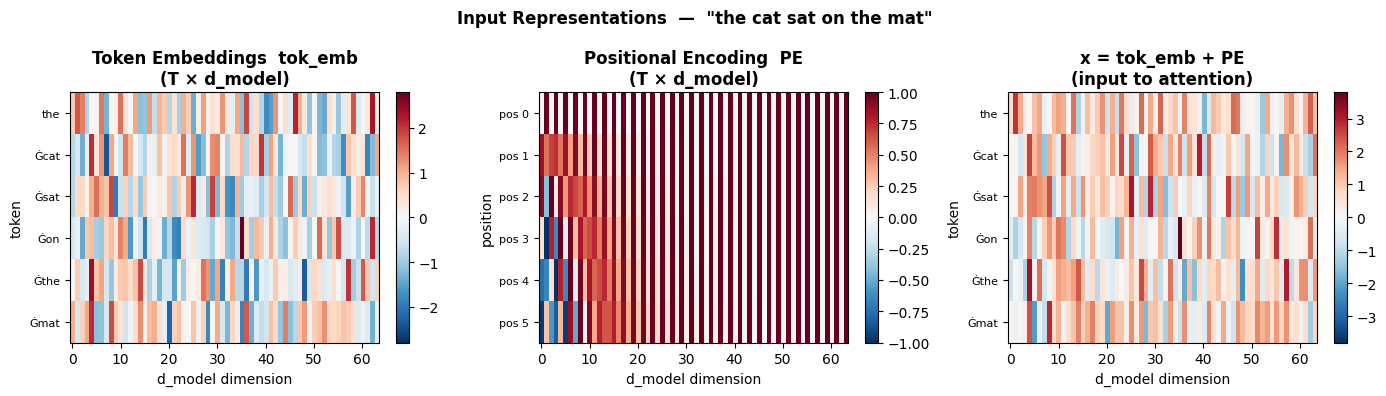


  Figure saved → '01_embeddings.png'


In [18]:
# ── 6. Visualise ──────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

def heatmap(ax, data, title, xlabel, ylabel, xticklabels=None):
    im = ax.imshow(data, aspect="auto", cmap="RdBu_r",
                   vmin=-data.abs().max().item(), vmax=data.abs().max().item())
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if xticklabels:
        ax.set_xticks(range(len(xticklabels)))
        ax.set_xticklabels(xticklabels, rotation=45, ha="right", fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046)

heatmap(axes[0], tok_emb.detach(),
        "Token Embeddings  tok_emb\n(T × d_model)",
        "d_model dimension", "token",
        xticklabels=None)
axes[0].set_yticks(range(T))
axes[0].set_yticklabels(tokens, fontsize=8)

heatmap(axes[1], pe,
        "Positional Encoding  PE\n(T × d_model)",
        "d_model dimension", "position")
axes[1].set_yticks(range(T))
axes[1].set_yticklabels([f"pos {i}" for i in range(T)], fontsize=8)

heatmap(axes[2], x.detach(),
        "x = tok_emb + PE\n(input to attention)",
        "d_model dimension", "token")
axes[2].set_yticks(range(T))
axes[2].set_yticklabels(tokens, fontsize=8)

plt.suptitle(f'Input Representations  —  "{SENTENCE}"', fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("01_embeddings.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  Figure saved → '01_embeddings.png'")